# Probability Simulation in Python

Probability is used to describe uncertain events.

Examples:

- tossing a coin
- rolling a die
- drawing a random number
- measuring noisy data

In this notebook, we use Python to simulate simple probability experiments.

We study:

1. Coin toss simulation
2. Dice roll simulation
3. Experimental probability
4. Theoretical probability
5. Convergence of probability with more trials

The main idea is:

When we repeat a random experiment many times, the experimental probability usually gets closer to the theoretical probability.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Coin Toss Simulation

A fair coin has two possible outcomes:

- Heads
- Tails

For a fair coin, the theoretical probability of heads is:

\[
P(\text{Heads}) = 0.5
\]

The theoretical probability of tails is also:

\[
P(\text{Tails}) = 0.5
\]

Now we simulate many coin tosses using Python.

In [37]:
# Set random seed so results are reproducible
np.random.seed(42)

# Number of coin tosses
n_tosses = 1000

# Represent Heads as 1 and Tails as 0
coin_tosses = np.random.choice([0, 1], size=n_tosses)

number_of_heads = np.sum(coin_tosses)
number_of_tails = n_tosses - number_of_heads

probability_heads = number_of_heads / n_tosses
probability_tails = number_of_tails / n_tosses

coin_table = pd.DataFrame({
    "Outcome": ["Heads", "Tails"],
    "Count": [number_of_heads, number_of_tails],
    "Experimental Probability": [probability_heads, probability_tails],
    "Theoretical Probability": [0.5, 0.5]
})

coin_table

,Outcome,Count,Experimental Probability,Theoretical Probability
0,Heads,510,0.51,0.5
1,Tails,490,0.49,0.5


## 2. Coin Toss Result Visualization

The bar plot compares the experimental probabilities with the theoretical probability.

For 1000 tosses, the result should be close to 0.5, but it may not be exactly 0.5 because the experiment is random.

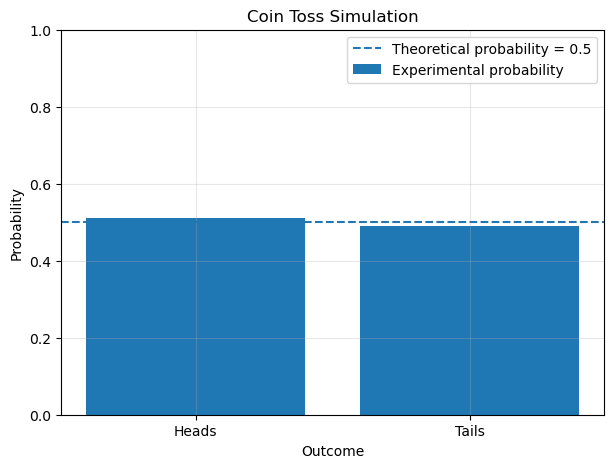

In [39]:
plt.figure(figsize=(7, 5))

plt.bar(coin_table["Outcome"], coin_table["Experimental Probability"], label="Experimental probability")
plt.axhline(0.5, linestyle="--", label="Theoretical probability = 0.5")

plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.title("Coin Toss Simulation")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Convergence of Coin Toss Probability

For a small number of tosses, the experimental probability can be far from 0.5.

As the number of tosses increases, the experimental probability usually gets closer to 0.5.

This is related to the Law of Large Numbers.

Glossary note:

**Law of Large Numbers** means that when a random experiment is repeated many times, the average result becomes closer to the theoretical expected value.

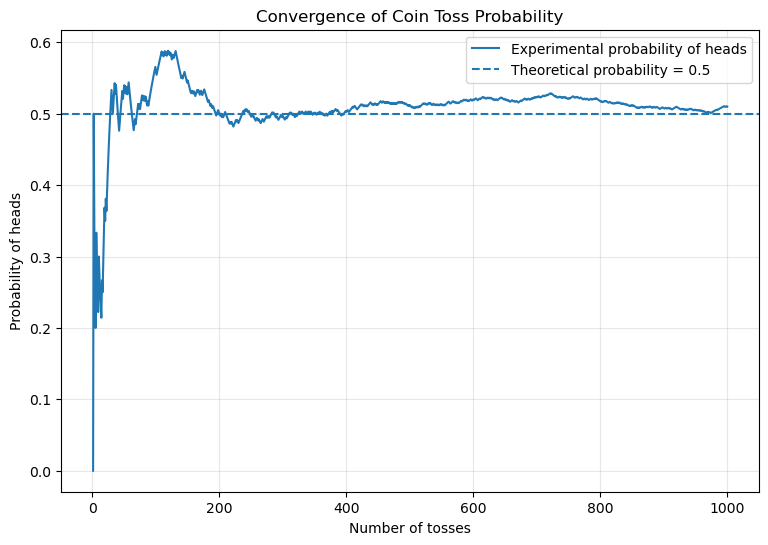

In [40]:
cumulative_heads = np.cumsum(coin_tosses)
toss_numbers = np.arange(1, n_tosses + 1)

running_probability_heads = cumulative_heads / toss_numbers

plt.figure(figsize=(9, 6))

plt.plot(toss_numbers, running_probability_heads, label="Experimental probability of heads")
plt.axhline(0.5, linestyle="--", label="Theoretical probability = 0.5")

plt.xlabel("Number of tosses")
plt.ylabel("Probability of heads")
plt.title("Convergence of Coin Toss Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

cumulative_heads = np.cumsum(coin_tosses)
toss_numbers = np.arange(1, n_tosses + 1)

running_probability_heads = cumulative_heads / toss_numbers

plt.figure(figsize=(9, 6))

plt.plot(toss_numbers, running_probability_heads, label="Experimental probability of heads")
plt.axhline(0.5, linestyle="--", label="Theoretical probability = 0.5")

plt.xlabel("Number of tosses")
plt.ylabel("Probability of heads")
plt.title("Convergence of Coin Toss Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [41]:
coin_error = abs(probability_heads - 0.5)

coin_error_table = pd.DataFrame({
    "Quantity": [
        "Experimental probability of heads",
        "Theoretical probability of heads",
        "Absolute error"
    ],
    "Value": [
        probability_heads,
        0.5,
        coin_error
    ]
})

coin_error_table

,Quantity,Value
0,Experimental probability of heads,0.51
1,Theoretical probability of heads,0.50
2,Absolute error,0.01


## 5. Coin Toss Error for Different Numbers of Tosses

Now we repeat the coin toss simulation using different numbers of tosses.

We check how the error changes when the number of tosses increases.

In [42]:
toss_counts = [10, 50, 100, 500, 1000, 5000, 10000]

coin_probabilities = []
coin_errors = []

for n in toss_counts:
    tosses = np.random.choice([0, 1], size=n)
    probability = np.sum(tosses) / n
    error = abs(probability - 0.5)
    
    coin_probabilities.append(probability)
    coin_errors.append(error)

coin_convergence_table = pd.DataFrame({
    "Number of tosses": toss_counts,
    "Experimental probability of heads": coin_probabilities,
    "Absolute error": coin_errors
})

coin_convergence_table

,Number of tosses,Experimental probability of heads,Absolute error
0,10,0.4000,0.1000
1,50,0.3800,0.1200
2,100,0.4800,0.0200
3,500,0.4840,0.0160
4,1000,0.4900,0.0100
5,5000,0.4994,0.0006
6,10000,0.4962,0.0038


## 6. Coin Toss Error Plot

The error does not always decrease perfectly because the process is random.

However, the general expectation is that larger numbers of tosses give more reliable probability estimates.

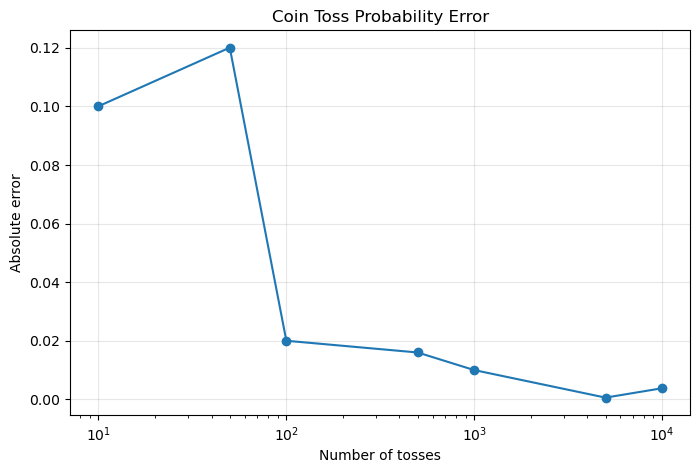

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(toss_counts, coin_errors, marker="o")

plt.xlabel("Number of tosses")
plt.ylabel("Absolute error")
plt.title("Coin Toss Probability Error")
plt.xscale("log")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Dice Roll Simulation

A fair six-sided die has six possible outcomes:

\[
1, 2, 3, 4, 5, 6
\]

For a fair die, each face has theoretical probability:

\[
P(1) = P(2) = P(3) = P(4) = P(5) = P(6) = \frac{1}{6}
\]

Now we simulate rolling a die many times.

In [46]:
n_rolls = 6000

dice_rolls = np.random.choice([1, 2, 3, 4, 5, 6], size=n_rolls)

faces, counts = np.unique(dice_rolls, return_counts=True)

experimental_probabilities = counts / n_rolls
theoretical_probabilities = np.ones(6) / 6

dice_table = pd.DataFrame({
    "Die Face": faces,
    "Count": counts,
    "Experimental Probability": experimental_probabilities,
    "Theoretical Probability": theoretical_probabilities
})

dice_table

,Die Face,Count,Experimental Probability,Theoretical Probability
0,1,982,0.163667,0.166667
1,2,1013,0.168833,0.166667
2,3,946,0.157667,0.166667
3,4,1015,0.169167,0.166667
4,5,1019,0.169833,0.166667
5,6,1025,0.170833,0.166667


## 8. Dice Roll Result Visualization

The bar plot shows the experimental probability of each die face.

The dashed horizontal line shows the theoretical probability:

\[
\frac{1}{6} \approx 0.1667
\]

For a large number of rolls, each face should appear with approximately equal probability.

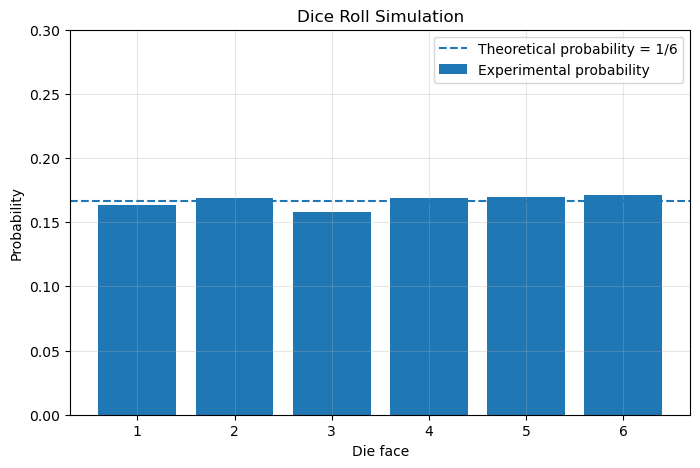

In [48]:
plt.figure(figsize=(8, 5))

plt.bar(dice_table["Die Face"], dice_table["Experimental Probability"], label="Experimental probability")
plt.axhline(1/6, linestyle="--", label="Theoretical probability = 1/6")

plt.xlabel("Die face")
plt.ylabel("Probability")
plt.title("Dice Roll Simulation")
plt.xticks(faces)
plt.ylim(0, 0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Dice Roll Error Analysis

For the die, we compare the experimental probability of each face with the theoretical probability.

For each face:

\[
\text{Absolute Error} = |P_{\text{experimental}} - P_{\text{theoretical}}|
\]

We also calculate the maximum error and mean error across all six faces.

In [49]:
dice_absolute_errors = np.abs(experimental_probabilities - theoretical_probabilities)

dice_error_table = pd.DataFrame({
    "Die Face": faces,
    "Experimental Probability": experimental_probabilities,
    "Theoretical Probability": theoretical_probabilities,
    "Absolute Error": dice_absolute_errors
})

dice_error_table

,Die Face,Experimental Probability,Theoretical Probability,Absolute Error
0,1,0.163667,0.166667,0.003000
1,2,0.168833,0.166667,0.002167
2,3,0.157667,0.166667,0.009000
3,4,0.169167,0.166667,0.002500
4,5,0.169833,0.166667,0.003167
5,6,0.170833,0.166667,0.004167


In [50]:
dice_error_summary = pd.DataFrame({
    "Quantity": [
        "Maximum absolute error",
        "Mean absolute error"
    ],
    "Value": [
        np.max(dice_absolute_errors),
        np.mean(dice_absolute_errors)
    ]
})

dice_error_summary

,Quantity,Value
0,Maximum absolute error,0.009
1,Mean absolute error,0.004


## 10. Dice Roll Convergence Study

Now we repeat the dice roll simulation with different numbers of rolls.

For each simulation, we calculate the maximum absolute error among the six die faces.

This helps us check whether the probability distribution becomes more accurate when the number of rolls increases.

In [51]:
roll_counts = [60, 120, 600, 1200, 6000, 12000, 60000]

dice_max_errors = []
dice_mean_errors = []

for n in roll_counts:
    rolls = np.random.choice([1, 2, 3, 4, 5, 6], size=n)
    
    counts = np.array([np.sum(rolls == face) for face in range(1, 7)])
    probabilities = counts / n
    
    errors = np.abs(probabilities - 1/6)
    
    dice_max_errors.append(np.max(errors))
    dice_mean_errors.append(np.mean(errors))

dice_convergence_table = pd.DataFrame({
    "Number of rolls": roll_counts,
    "Maximum absolute error": dice_max_errors,
    "Mean absolute error": dice_mean_errors
})

dice_convergence_table

,Number of rolls,Maximum absolute error,Mean absolute error
0,60,0.100000,0.083333
1,120,0.050000,0.033333
2,600,0.045000,0.017778
3,1200,0.016667,0.008611
4,6000,0.006833,0.004333
5,12000,0.012667,0.006111
6,60000,0.002783,0.001239


## 11. Dice Roll Error Plot

The error usually becomes smaller when the number of rolls increases.

The decrease is not perfectly smooth because random simulations fluctuate.

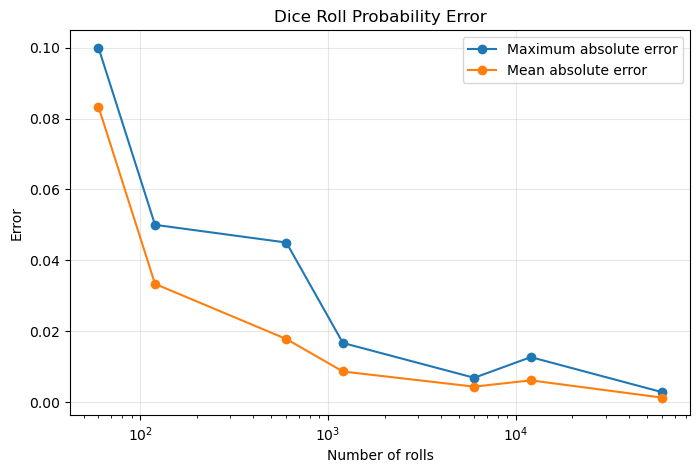

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(roll_counts, dice_max_errors, marker="o", label="Maximum absolute error")
plt.plot(roll_counts, dice_mean_errors, marker="o", label="Mean absolute error")

plt.xlabel("Number of rolls")
plt.ylabel("Error")
plt.title("Dice Roll Probability Error")
plt.xscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Discussion

From the simulations, we observe:

1. A fair coin should give heads and tails with probability close to 0.5.
2. A fair die should give each face with probability close to \(1/6\).
3. For a small number of trials, experimental probabilities can differ noticeably from theoretical probabilities.
4. When the number of trials increases, the experimental probability usually becomes closer to the theoretical probability.
5. The error does not decrease perfectly smoothly because the experiment is random.
6. These simulations demonstrate the Law of Large Numbers.

This notebook shows how Python can be used to simulate basic probability experiments and compare experimental results with theoretical expectations.

## 13. Conclusion

In this notebook, we simulated two basic probability experiments:

- coin tosses
- dice rolls

For both experiments, we compared experimental probabilities with theoretical probabilities.

The main conclusion is:

When a random experiment is repeated many times, the experimental probability tends to approach the theoretical probability.

This is an important idea in probability, statistics, simulations, and data analysis.